# Analysis of the relationship between deprivation and early years performance in England

An analysis to ...

### Imports

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from config import DATABASE_PATH, PROJECT_ROOT

### Gather data

First, we need to check whether both datasets (EYFSP and IMD) have the same local authority districts (LADs) and whether there are any mismatches in the LAD codes or names between the two datasets. This is crucial to ensure that we can accurately link the EYFSP performance data with the corresponding deprivation data from the IMD.

In [2]:
# Check for mismatches between EYFSP and IMD data

# -- Left join EYFSP to IMD to find EYFSP records without a match in IMD
query = ("select eyfsp.lad_code, eyfsp.lad_name, imd.la_code, imd.la_name "
         "from eyfsp "
         "left join imd on eyfsp.lad_code = imd.la_code "
         "where imd.la_code is NULL")
with sqlite3.connect(DATABASE_PATH) as conn:
    eyfsp_join = pd.read_sql_query(query, conn)

# -- Left join IMD to EYFSP to find IMD records without a match in EYFSP
query = ("select eyfsp.lad_code, eyfsp.lad_name, imd.la_code, imd.la_name "
         "from imd "
         "left join eyfsp on imd.la_code = eyfsp.lad_code "
         "where eyfsp.lad_code is NULL")
with sqlite3.connect(DATABASE_PATH) as conn:
    imd_join = pd.read_sql_query(query, conn)

if eyfsp_join.empty and imd_join.empty:
    print("No mismatches between EYFSP and IMD data.")
else:
    print("Mismatches found between EYFSP and IMD data:")
    print(f"EYFSP districts without IMD matches:\n{eyfsp_join.lad_name.unique()}")
    print(f"IMD districts without EYFSP matches:\n{imd_join.la_name.unique()}")

Mismatches found between EYFSP and IMD data:
EYFSP districts without IMD matches:
<StringArray>
[                             nan,                     'Cumberland',
        'Westmorland and Furness',                       'Barnsley',
                'North Yorkshire',                      'Sheffield',
         'North Northamptonshire',          'West Northamptonshire',
                'Buckinghamshire',                       'Somerset',
 'Outside of England and unknown']
Length: 11, dtype: str
IMD districts without EYFSP matches:
<StringArray>
[        'Aylesbury Vale',               'Chiltern',            'South Bucks',
                'Wycombe',                  'Corby',               'Daventry',
  'East Northamptonshire',              'Kettering',            'Northampton',
 'South Northamptonshire',         'Wellingborough']
Length: 11, dtype: str


These mismatches are likely due to local government restructuring between 2019 (when the IMD was published) and 2021–2025 (the EYFSP data). Let's count how many districts are matched vs unmatched to understand the scale of the issue.

In [3]:
# Count matched vs unmatched districts
query = """
    select count(distinct eyfsp.lad_code) as total_eyfsp_districts
    from eyfsp
    where geographic_level = 'Local authority district'
      and lad_code != 'z'
      and lad_code is not null
"""
with sqlite3.connect(DATABASE_PATH) as conn:
    total = pd.read_sql_query(query, conn).iloc[0, 0]

query = """
    select count(distinct eyfsp.lad_code) as matched_districts
    from eyfsp
    inner join imd on eyfsp.lad_code = imd.la_code
    where eyfsp.geographic_level = 'Local authority district'
"""
with sqlite3.connect(DATABASE_PATH) as conn:
    matched = pd.read_sql_query(query, conn).iloc[0, 0]

print(f"Matched {matched} of {total} EYFSP districts ({matched/total:.0%}) to IMD records.")
print(f"Dropped {total - matched} districts due to restructuring or code changes.")

Matched 306 of 315 EYFSP districts (97%) to IMD records.
Dropped 9 districts due to restructuring or code changes.


Within the scope of these analyses, this 3% loss is minimal enough that we can proceed with the analysis using the matched districts without needing to remap districts.

Now we can construct a new table that combines the EYFSP performance data with the corresponding IMD deprivation data for each local authority district. This will allow us to analyze the relationship between deprivation and early years performance.

In [4]:
with open(Path(PROJECT_ROOT / "sql" / "EYFSP_and_IMD.sql")) as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df = pd.read_sql_query(query, conn)

print(df)

      lad_code              lad_name  children_count  gld_children_count  \
0    E06000047         County Durham            4861                3163   
1    E06000005            Darlington            1132                 735   
2    E08000037             Gateshead            1912                1271   
3    E06000001            Hartlepool            1024                 666   
4    E06000002         Middlesbrough            1794                1106   
..         ...                   ...             ...                 ...   
282  E09000024                Merton            1951                1386   
283  E09000026             Redbridge            4009                2923   
284  E09000027  Richmond upon Thames            2156                1661   
285  E09000029                Sutton            2452                1716   
286  E09000031        Waltham Forest            3211                2404   

     gld_children_percent  imd_score  
0               65.068915     26.793  
1        

Check for missing data and correct data types to ensure the data is clean and ready for analysis.

In [5]:
# Check for missing IMD scores

if df["imd_score"].isna().any():
    # Check how many records have missing IMD scores
    missing_count = df["imd_score"].isna().sum()
    total_count = len(df)
    print(f"Warning: {missing_count} out of {total_count} records have missing")
elif df["gld_children_percent"].isna().any():
    missing_count = df["gld_children_percent"].isna().sum()
    total_count = len(df)
    print(f"Warning: {missing_count} out of {total_count} records have missing GLD percentages.")
else:
    print("No missing data found.")


No missing data found.


In [6]:
# Check data types and adjust where necessary
print(f"Data type of imd_score: {df['imd_score'].dtype}")
print(f"Data type of gld_children_percent: {df['gld_children_percent'].dtype}")
print(f"Data type of gld_children_count: {df['gld_children_count'].dtype}")

Data type of imd_score: float64
Data type of gld_children_percent: float64
Data type of gld_children_count: int64


Now we can perform a simple linear regression analysis to examine the relationship between the IMD score (as a measure of deprivation) and the percentage of children achieving a good level of development (GLD) in the EYFSP. The IMD score is typically higher for more deprived areas, so we would expect to see a negative relationship if deprivation is associated with lower EYFSP performance.

In [7]:
X = df["imd_score"]
y = df["gld_children_percent"]

if len(X) != len(y):
    raise ValueError("Mismatched lengths between features and target variable.")

print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

model = sm.OLS(y, sm.add_constant(X)).fit()
print(model.summary())



Shape of X: (287,), Shape of y: (287,)
                             OLS Regression Results                             
Dep. Variable:     gld_children_percent   R-squared:                       0.447
Model:                              OLS   Adj. R-squared:                  0.445
Method:                   Least Squares   F-statistic:                     230.2
Date:                  Fri, 22 May 2026   Prob (F-statistic):           1.60e-38
Time:                          16:43:44   Log-Likelihood:                -716.03
No. Observations:                   287   AIC:                             1436.
Df Residuals:                       285   BIC:                             1443.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

Text(0.5, 1.0, 'School Readiness vs Deprivation (2024/25)')

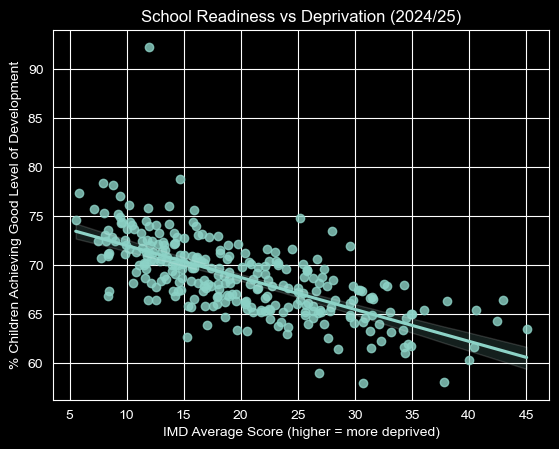

In [8]:
ax = sns.regplot(df, x="imd_score", y="gld_children_percent")
ax.set_xlabel("IMD Average Score (higher = more deprived)")
ax.set_ylabel("% Children Achieving Good Level of Development")
ax.set_title("School Readiness vs Deprivation (2024/25)")

<Axes: xlabel='imd_score', ylabel='gld_children_percent'>

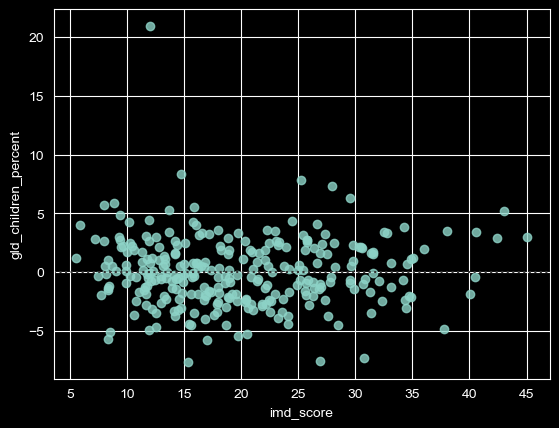

In [9]:
sns.residplot(df, x="imd_score", y="gld_children_percent")

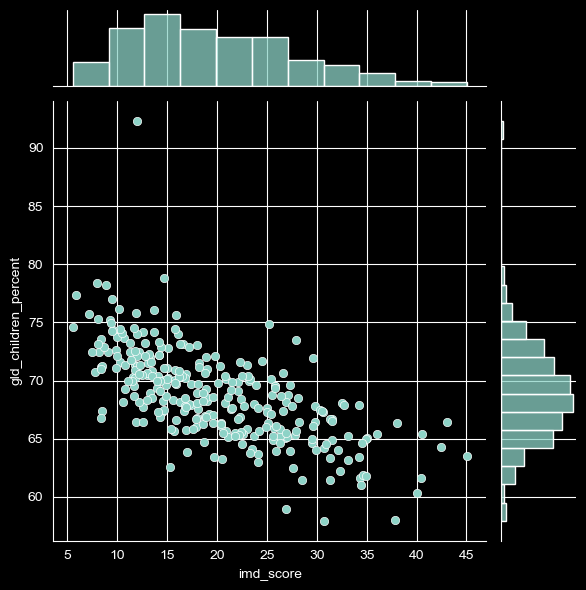

In [10]:
sns.jointplot(df, x="imd_score", y="gld_children_percent")

In [11]:
px.scatter(df, x="imd_score", y="gld_children_percent", hover_name="lad_name", trendline="ols")

Now we can explore the residuals to identify any outliers or patterns that may indicate a non-linear relationship or other factors influencing the results. We can look at the largest positive and negative residuals to see which districts are performing better or worse than expected based on their deprivation levels.

In [13]:
df["residual"] = model.resid

# Districts performing better than deprivation predicts
positive_resid = df.nlargest(10, "residual")[["lad_name", "imd_score", "gld_children_percent", "residual"]]

# Districts performing worse than deprivation predicts
negative_resid = df.nsmallest(10, "residual")[["lad_name", "imd_score", "gld_children_percent", "residual"]]

print(f"Districts performing better than expected based on deprivation:\n{positive_resid}")
print(f"Districts performing worse than expected based on deprivation:\n{negative_resid}")

Districts performing better than expected based on deprivation:
            lad_name  imd_score  gld_children_percent   residual
247  Isles of Scilly     12.005             92.307692  20.953528
255   City of London     14.720             78.787878   8.320609
286   Waltham Forest     25.209             74.867642   7.826759
258         Haringey     27.956             73.496240   7.352704
263           Newham     29.577             71.925699   6.311687
208  Epsom and Ewell      8.833             78.225806   5.835462
207        Elmbridge      7.944             78.400000   5.719251
22             Fylde     15.875             75.606060   5.516089
236       South Hams     13.724             76.029962   5.237335
19          Knowsley     43.006             66.437964   5.210732
Districts performing worse than expected based on deprivation:
                 lad_name  imd_score  gld_children_percent  residual
29           South Ribble     15.330             62.612163 -7.655841
76                Li

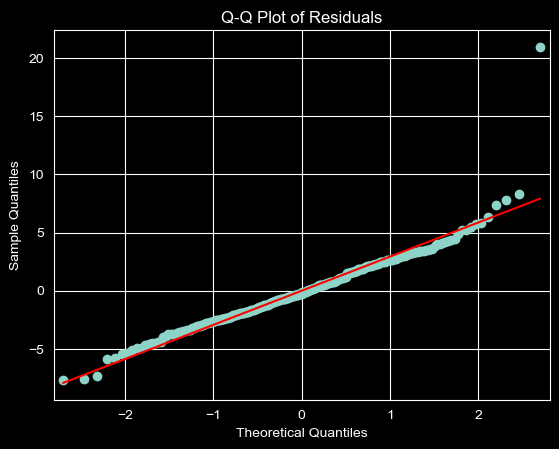

In [15]:
from statsmodels.graphics.gofplots import qqplot
qqplot(df["residual"], line="s")
plt.title("Q-Q Plot of Residuals")
plt.show()

Here we can see the relationship is real and strong but there are some districts with better early years development than its deprivation would predict, and also some districts doing worse than expected based on deprivation levels. Now we can try understand what other factors might be able to explain the remaining variance (the residuals) in the EYFSP performance that is not explained by deprivation alone.